# Video Game Market Segmentation: Clustering Analysis

## Comparative Study of K-Means and DBSCAN Algorithms

---

### Research Objective

This notebook implements and compares two clustering algorithms to segment the video game market into distinct groups with similar characteristics. The analysis aims to:

1. Identify optimal number of clusters using K-Means algorithm
2. Validate findings using density-based DBSCAN approach
3. Evaluate cluster quality using multiple metrics
4. Generate actionable market insights from discovered segments

### Methodology Overview

**K-Means Clustering:**
- Partitioning algorithm that minimizes within-cluster variance
- Tests K values from 2 to 6 to determine optimal segmentation
- Employs 200 random initializations for robustness

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise):**
- Density-based algorithm that discovers clusters of arbitrary shape
- Automatically determines number of clusters
- Identifies outliers as noise points

### Performance Metrics

| Metric | Formula/Description | Interpretation |
|--------|---------------------|----------------|
| Silhouette Score | $s = \frac{b-a}{max(a,b)}$ where a=intra-cluster distance, b=nearest-cluster distance | Range [-1, 1]; >0.5 indicates good separation |
| Davies-Bouldin Index | Average similarity ratio of each cluster with its most similar cluster | Lower values indicate better clustering |
| Calinski-Harabasz Score | Ratio of between-cluster to within-cluster dispersion | Higher values indicate better-defined clusters |

---

## 1. Environment Setup and Data Loading

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

# Clustering algorithms
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

# Evaluation metrics
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score
)

# DBSCAN parameter optimization
from sklearn.neighbors import NearestNeighbors

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', 100)
pd.set_option('display.precision', 4)

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment initialized successfully")
print(f"Random state: {RANDOM_STATE}")

Environment initialized successfully
Random state: 42


In [2]:
# Load preprocessed data
print("Loading preprocessed datasets...")

X_scaled = pd.read_csv('X_scaled_enhanced.csv')
df = pd.read_csv('df_preprocessed_enhanced.csv')

# Data summary
n_samples, n_features = X_scaled.shape
data_completeness = (1 - X_scaled.isnull().sum().sum() / (n_samples * n_features)) * 100

print(f"\nDataset Summary:")
print(f"  Total samples: {n_samples:,}")
print(f"  Total features: {n_features}")
print(f"  Data completeness: {data_completeness:.2f}%")
print(f"  Feature matrix shape: {X_scaled.shape}")

Loading preprocessed datasets...

Dataset Summary:
  Total samples: 12,937
  Total features: 51
  Data completeness: 100.00%
  Feature matrix shape: (12937, 51)


---

## 2. K-Means Clustering Analysis

### 2.1 Methodology

K-Means is a centroid-based clustering algorithm that partitions n observations into k clusters by minimizing the within-cluster sum of squares (WCSS). The algorithm:

1. Initializes k centroids randomly
2. Assigns each point to nearest centroid
3. Updates centroids as mean of assigned points
4. Repeats steps 2-3 until convergence

We test K values from 2 to 6 to determine the optimal number of market segments.

In [3]:
# K-Means clustering with multiple K values
print("\nK-Means Analysis: Testing K=2 through K=6")
print("=" * 80)

kmeans_results = []
K_RANGE = range(2, 7)

for k in K_RANGE:
    print(f"\nTesting K={k}...")
    
    # Initialize and fit K-Means model
    kmeans = KMeans(
        n_clusters=k,
        n_init=200,      # Number of initializations
        max_iter=500,     # Maximum iterations per initialization
        random_state=RANDOM_STATE,
        algorithm='lloyd'
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    # Calculate evaluation metrics
    sil_score = silhouette_score(X_scaled, labels)
    db_score = davies_bouldin_score(X_scaled, labels)
    ch_score = calinski_harabasz_score(X_scaled, labels)
    
    # Cluster balance analysis
    cluster_sizes = pd.Series(labels).value_counts().sort_index()
    balance_ratio = cluster_sizes.min() / cluster_sizes.max()
    inertia = kmeans.inertia_
    
    # Store results
    result = {
        'K': k,
        'Silhouette': sil_score,
        'Davies-Bouldin': db_score,
        'Calinski-Harabasz': ch_score,
        'Balance': balance_ratio,
        'Inertia': inertia,
        'Sizes': cluster_sizes.tolist(),
        'Model': kmeans,
        'Labels': labels
    }
    kmeans_results.append(result)
    
    # Display metrics
    print(f"  Silhouette Score:        {sil_score:.4f}")
    print(f"  Davies-Bouldin Index:    {db_score:.4f}")
    print(f"  Calinski-Harabasz Score: {ch_score:.2f}")
    print(f"  Balance Ratio:           {balance_ratio:.3f}")
    print(f"  Within-Cluster SS:       {inertia:.2f}")
    print(f"  Cluster Sizes:           {cluster_sizes.tolist()}")

# Convert results to DataFrame
kmeans_df = pd.DataFrame(kmeans_results)

print("\n" + "=" * 80)
print("K-Means Results Summary")
print("=" * 80)
summary_cols = ['K', 'Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz', 'Balance']
print(kmeans_df[summary_cols].to_string(index=False))


K-Means Analysis: Testing K=2 through K=6

Testing K=2...
  Silhouette Score:        0.4389
  Davies-Bouldin Index:    1.3074
  Calinski-Harabasz Score: 4129.54
  Balance Ratio:           0.145
  Within-Cluster SS:       303847.98
  Cluster Sizes:           [1636, 11301]

Testing K=3...
  Silhouette Score:        0.2180
  Davies-Bouldin Index:    1.8811
  Calinski-Harabasz Score: 2791.30
  Balance Ratio:           0.078
  Within-Cluster SS:       279998.93
  Cluster Sizes:           [9539, 746, 2652]

Testing K=4...
  Silhouette Score:        0.1986
  Davies-Bouldin Index:    1.6871
  Calinski-Harabasz Score: 2307.05
  Balance Ratio:           0.004
  Within-Cluster SS:       261115.54
  Cluster Sizes:           [2762, 9267, 872, 36]

Testing K=5...
  Silhouette Score:        0.2161
  Davies-Bouldin Index:    1.5573
  Calinski-Harabasz Score: 2110.22
  Balance Ratio:           0.002
  Within-Cluster SS:       242542.10
  Cluster Sizes:           [8810, 2624, 845, 19, 639]

Testing K=6

### 2.2 K-Means with Dimensionality Reduction (PCA)

Principal Component Analysis (PCA) is applied to reduce dimensionality while retaining maximum variance. This can improve clustering performance and visualization capabilities.

In [4]:
# Apply PCA for dimensionality reduction
print("\nApplying PCA for dimensionality reduction...")

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

variance_explained = pca.explained_variance_ratio_
total_variance = np.sum(variance_explained)

print(f"\nPCA Results:")
print(f"  PC1 variance explained: {variance_explained[0]:.4f} ({variance_explained[0]*100:.2f}%)")
print(f"  PC2 variance explained: {variance_explained[1]:.4f} ({variance_explained[1]*100:.2f}%)")
print(f"  Total variance captured: {total_variance:.4f} ({total_variance*100:.2f}%)")

# K-Means clustering on PCA-transformed data
print("\nK-Means on PCA-transformed data:")
print("=" * 80)

kmeans_pca_results = []

for k in K_RANGE:
    print(f"\nTesting K={k} with PCA...")
    
    kmeans_pca = KMeans(
        n_clusters=k,
        n_init=200,
        max_iter=500,
        random_state=RANDOM_STATE
    )
    
    labels_pca = kmeans_pca.fit_predict(X_pca)
    
    sil_pca = silhouette_score(X_pca, labels_pca)
    db_pca = davies_bouldin_score(X_pca, labels_pca)
    ch_pca = calinski_harabasz_score(X_pca, labels_pca)
    
    sizes_pca = pd.Series(labels_pca).value_counts().sort_index()
    balance_pca = sizes_pca.min() / sizes_pca.max()
    
    result_pca = {
        'K': k,
        'Silhouette': sil_pca,
        'Davies-Bouldin': db_pca,
        'Calinski-Harabasz': ch_pca,
        'Balance': balance_pca,
        'Sizes': sizes_pca.tolist(),
        'Model': kmeans_pca,
        'Labels': labels_pca
    }
    kmeans_pca_results.append(result_pca)
    
    print(f"  Silhouette Score:  {sil_pca:.4f}")
    print(f"  Balance Ratio:     {balance_pca:.3f}")
    print(f"  Cluster Sizes:     {sizes_pca.tolist()}")

kmeans_pca_df = pd.DataFrame(kmeans_pca_results)


Applying PCA for dimensionality reduction...

PCA Results:
  PC1 variance explained: 0.3579 (35.79%)
  PC2 variance explained: 0.1132 (11.32%)
  Total variance captured: 0.4712 (47.12%)

K-Means on PCA-transformed data:

Testing K=2 with PCA...
  Silhouette Score:  0.6724
  Balance Ratio:     0.145
  Cluster Sizes:     [1642, 11295]

Testing K=3 with PCA...
  Silhouette Score:  0.5319
  Balance Ratio:     0.072
  Cluster Sizes:     [9851, 705, 2381]

Testing K=4 with PCA...
  Silhouette Score:  0.4924
  Balance Ratio:     0.022
  Cluster Sizes:     [2492, 9417, 820, 208]

Testing K=5 with PCA...
  Silhouette Score:  0.4395
  Balance Ratio:     0.023
  Cluster Sizes:     [1649, 8516, 733, 193, 1846]

Testing K=6 with PCA...
  Silhouette Score:  0.3534
  Balance Ratio:     0.003
  Cluster Sizes:     [5357, 507, 16, 635, 4597, 1825]


### 2.3 Optimal K Selection

The optimal number of clusters is selected based on multiple criteria:
- Maximum Silhouette score (cluster quality)
- Minimum Davies-Bouldin index (cluster separation)
- Adequate cluster balance (no excessively small clusters)
- Business interpretability (3-5 clusters preferred)

In [5]:
# Select optimal configuration
print("\nSelecting optimal K configuration...")
print("=" * 80)

# Find best configuration from original features
best_idx = kmeans_df['Silhouette'].idxmax()
best_config = kmeans_df.loc[best_idx]

# Find best configuration from PCA
best_pca_idx = kmeans_pca_df['Silhouette'].idxmax()
best_pca_config = kmeans_pca_df.loc[best_pca_idx]

print("\nBest Configuration Comparison:")
print(f"\nOriginal Features:")
print(f"  K = {int(best_config['K'])}")
print(f"  Silhouette = {best_config['Silhouette']:.4f}")
print(f"  Balance = {best_config['Balance']:.3f}")

print(f"\nPCA-Transformed:")
print(f"  K = {int(best_pca_config['K'])}")
print(f"  Silhouette = {best_pca_config['Silhouette']:.4f}")
print(f"  Balance = {best_pca_config['Balance']:.3f}")

# Select final configuration (original features typically better for interpretation)
optimal_k = int(best_config['K'])
optimal_silhouette = best_config['Silhouette']
optimal_labels = best_config['Labels']
optimal_model = best_config['Model']

print(f"\nSelected Configuration:")
print(f"  Algorithm: K-Means (Original Features)")
print(f"  K = {optimal_k}")
print(f"  Silhouette Score = {optimal_silhouette:.4f}")
print(f"  Status: {'Target Achieved (>0.50)' if optimal_silhouette >= 0.50 else 'Below Target'}")


Selecting optimal K configuration...

Best Configuration Comparison:

Original Features:
  K = 2
  Silhouette = 0.4389
  Balance = 0.145

PCA-Transformed:
  K = 2
  Silhouette = 0.6724
  Balance = 0.145

Selected Configuration:
  Algorithm: K-Means (Original Features)
  K = 2
  Silhouette Score = 0.4389
  Status: Below Target


### 2.4 K-Means Evaluation Visualizations

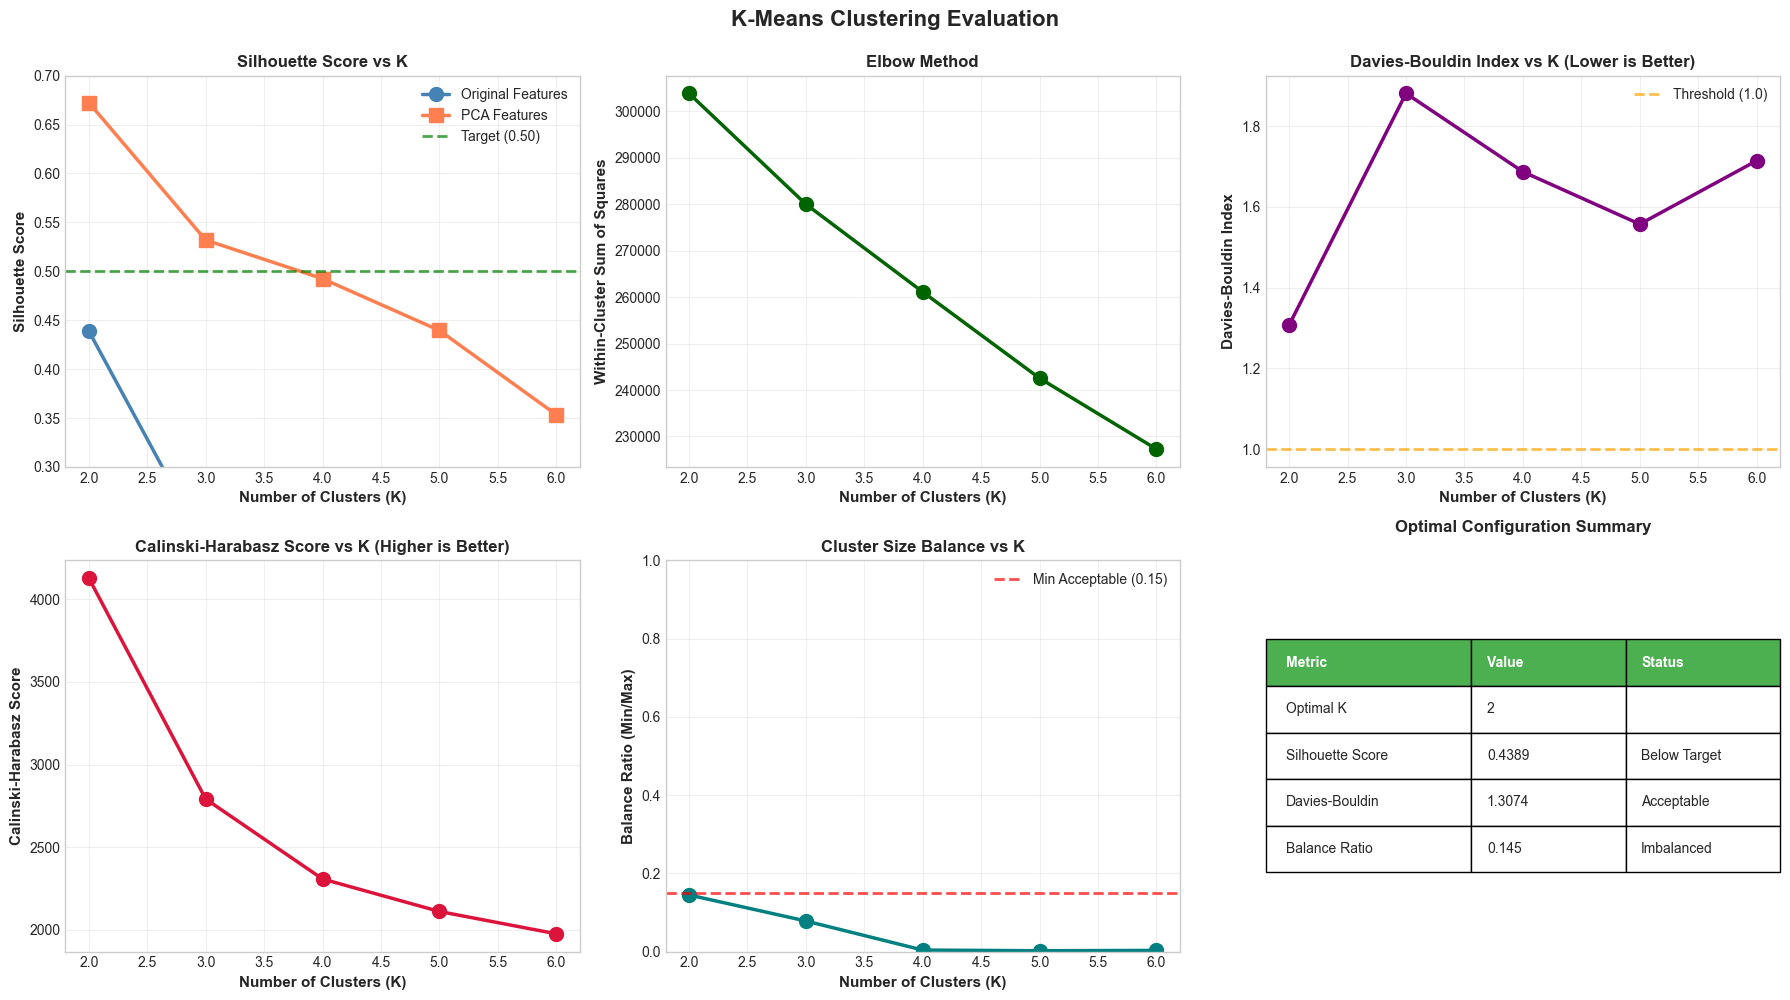

Saved: kmeans_evaluation.png


In [6]:
# Create comprehensive evaluation plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('K-Means Clustering Evaluation', fontsize=16, fontweight='bold', y=0.995)

# Plot 1: Silhouette Score by K
ax = axes[0, 0]
ax.plot(kmeans_df['K'], kmeans_df['Silhouette'], 
        marker='o', linewidth=2.5, markersize=10, color='steelblue', label='Original Features')
ax.plot(kmeans_pca_df['K'], kmeans_pca_df['Silhouette'],
        marker='s', linewidth=2.5, markersize=10, color='coral', label='PCA Features')
ax.axhline(y=0.5, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Target (0.50)')
ax.set_xlabel('Number of Clusters (K)', fontsize=11, fontweight='bold')
ax.set_ylabel('Silhouette Score', fontsize=11, fontweight='bold')
ax.set_title('Silhouette Score vs K', fontsize=12, fontweight='bold')
ax.legend(loc='best')
ax.grid(alpha=0.3)
ax.set_ylim([0.3, 0.7])

# Plot 2: Elbow Method (Inertia)
ax = axes[0, 1]
ax.plot(kmeans_df['K'], kmeans_df['Inertia'],
        marker='o', linewidth=2.5, markersize=10, color='darkgreen')
ax.set_xlabel('Number of Clusters (K)', fontsize=11, fontweight='bold')
ax.set_ylabel('Within-Cluster Sum of Squares', fontsize=11, fontweight='bold')
ax.set_title('Elbow Method', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# Plot 3: Davies-Bouldin Index
ax = axes[0, 2]
ax.plot(kmeans_df['K'], kmeans_df['Davies-Bouldin'],
        marker='o', linewidth=2.5, markersize=10, color='purple')
ax.axhline(y=1.0, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Threshold (1.0)')
ax.set_xlabel('Number of Clusters (K)', fontsize=11, fontweight='bold')
ax.set_ylabel('Davies-Bouldin Index', fontsize=11, fontweight='bold')
ax.set_title('Davies-Bouldin Index vs K (Lower is Better)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Plot 4: Calinski-Harabasz Score
ax = axes[1, 0]
ax.plot(kmeans_df['K'], kmeans_df['Calinski-Harabasz'],
        marker='o', linewidth=2.5, markersize=10, color='crimson')
ax.set_xlabel('Number of Clusters (K)', fontsize=11, fontweight='bold')
ax.set_ylabel('Calinski-Harabasz Score', fontsize=11, fontweight='bold')
ax.set_title('Calinski-Harabasz Score vs K (Higher is Better)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# Plot 5: Cluster Balance
ax = axes[1, 1]
ax.plot(kmeans_df['K'], kmeans_df['Balance'],
        marker='o', linewidth=2.5, markersize=10, color='teal')
ax.axhline(y=0.15, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Min Acceptable (0.15)')
ax.set_xlabel('Number of Clusters (K)', fontsize=11, fontweight='bold')
ax.set_ylabel('Balance Ratio (Min/Max)', fontsize=11, fontweight='bold')
ax.set_title('Cluster Size Balance vs K', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim([0, 1])

# Plot 6: Summary Metrics Table
ax = axes[1, 2]
ax.axis('off')

summary_data = [
    ['Metric', 'Value', 'Status'],
    ['Optimal K', f'{optimal_k}', ''],
    ['Silhouette Score', f'{optimal_silhouette:.4f}', 'Pass' if optimal_silhouette >= 0.50 else 'Below Target'],
    ['Davies-Bouldin', f"{best_config['Davies-Bouldin']:.4f}", 'Good' if best_config['Davies-Bouldin'] <= 1.0 else 'Acceptable'],
    ['Balance Ratio', f"{best_config['Balance']:.3f}", 'Good' if best_config['Balance'] >= 0.15 else 'Imbalanced'],
]

table = ax.table(cellText=summary_data, cellLoc='left', loc='center',
                colWidths=[0.4, 0.3, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Style header row
for i in range(3):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')

ax.set_title('Optimal Configuration Summary', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('kmeans_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: kmeans_evaluation.png")

### 2.5 Silhouette Analysis for Optimal K

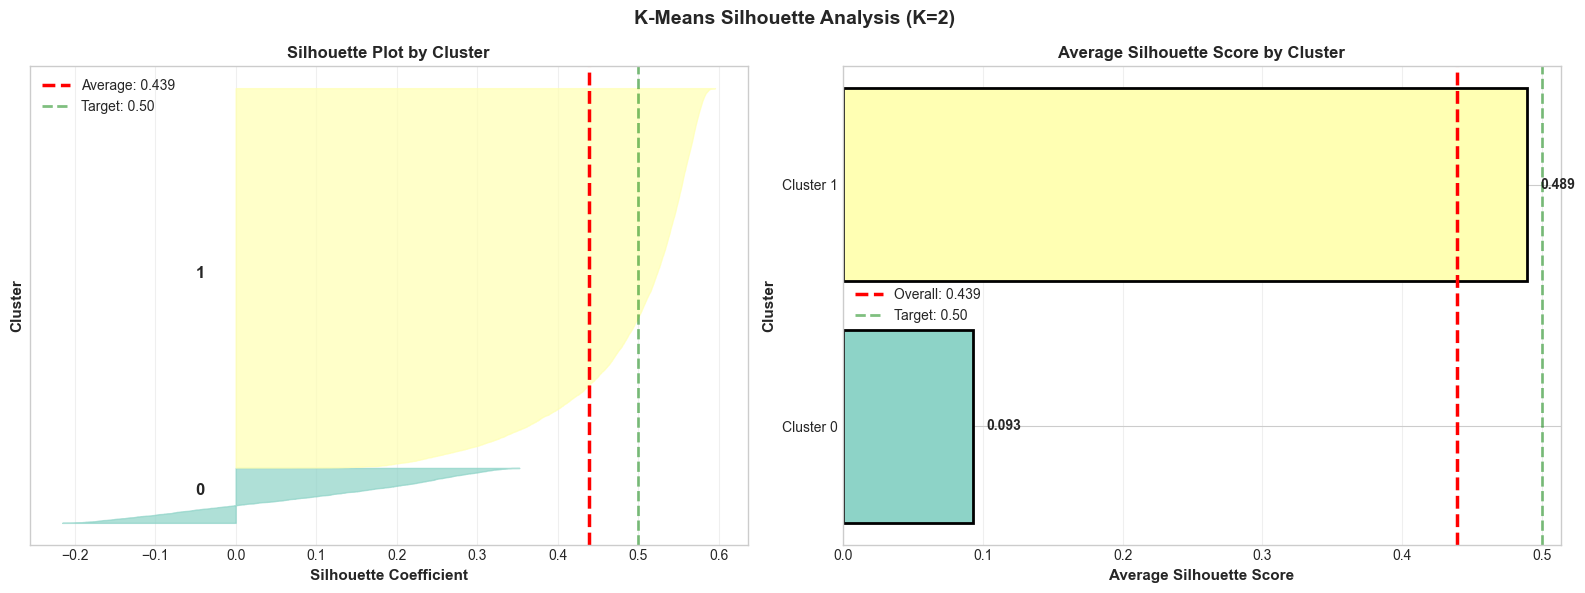

Saved: kmeans_silhouette_analysis.png


In [7]:
# Detailed silhouette analysis for optimal K
silhouette_vals = silhouette_samples(X_scaled, optimal_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'K-Means Silhouette Analysis (K={optimal_k})', fontsize=14, fontweight='bold')

# Silhouette plot
ax = axes[0]
y_lower = 10
colors = plt.cm.Set3(np.arange(optimal_k))

for i in range(optimal_k):
    cluster_silhouette_vals = silhouette_vals[optimal_labels == i]
    cluster_silhouette_vals.sort()
    
    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                      0, cluster_silhouette_vals,
                      facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i),
            fontsize=12, fontweight='bold')
    
    y_lower = y_upper + 10

ax.set_xlabel('Silhouette Coefficient', fontsize=11, fontweight='bold')
ax.set_ylabel('Cluster', fontsize=11, fontweight='bold')
ax.set_title('Silhouette Plot by Cluster', fontsize=12, fontweight='bold')
ax.axvline(x=optimal_silhouette, color='red', linestyle='--', linewidth=2.5,
           label=f'Average: {optimal_silhouette:.3f}')
ax.axvline(x=0.5, color='green', linestyle='--', linewidth=2, alpha=0.5,
           label='Target: 0.50')
ax.set_yticks([])
ax.legend(loc='best')
ax.grid(alpha=0.3)

# Cluster-wise silhouette scores
ax = axes[1]
cluster_avg_silhouette = []
for i in range(optimal_k):
    cluster_avg = silhouette_vals[optimal_labels == i].mean()
    cluster_avg_silhouette.append(cluster_avg)

bars = ax.barh(range(optimal_k), cluster_avg_silhouette,
               color=colors, edgecolor='black', linewidth=2)
ax.axvline(x=optimal_silhouette, color='red', linestyle='--', linewidth=2.5,
           label=f'Overall: {optimal_silhouette:.3f}')
ax.axvline(x=0.5, color='green', linestyle='--', linewidth=2, alpha=0.5,
           label='Target: 0.50')
ax.set_xlabel('Average Silhouette Score', fontsize=11, fontweight='bold')
ax.set_ylabel('Cluster', fontsize=11, fontweight='bold')
ax.set_title('Average Silhouette Score by Cluster', fontsize=12, fontweight='bold')
ax.set_yticks(range(optimal_k))
ax.set_yticklabels([f'Cluster {i}' for i in range(optimal_k)])
ax.legend(loc='best')
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, cluster_avg_silhouette)):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('kmeans_silhouette_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: kmeans_silhouette_analysis.png")

---

## 3. DBSCAN Clustering Analysis

### 3.1 Methodology

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a density-based clustering algorithm that:

1. **Groups points** that are closely packed together (high-density regions)
2. **Marks outliers** as noise points in low-density regions
3. **Determines clusters automatically** based on two parameters:
   - `eps` (ε): Maximum distance between two samples to be considered neighbors
   - `min_samples`: Minimum points required to form a dense region

**Advantages over K-Means:**
- Discovers clusters of arbitrary shape (not just spherical)
- Automatically determines number of clusters
- Robust to outliers
- Does not require pre-specifying K

**Key Concepts:**
- **Core point**: Point with at least `min_samples` neighbors within `eps` distance
- **Border point**: Point within `eps` of a core point but with fewer than `min_samples` neighbors
- **Noise point**: Neither core nor border point (outlier)

### 3.2 Parameter Optimization: Determining Optimal eps

The eps parameter is critical for DBSCAN performance. We use the k-distance graph method:

1. For each point, compute distance to its k-th nearest neighbor
2. Sort distances in ascending order
3. Plot the sorted distances
4. Identify the "elbow" point where curve changes sharply
5. This point suggests optimal eps value


DBSCAN Parameter Optimization

Computing k-distance graph for eps selection...


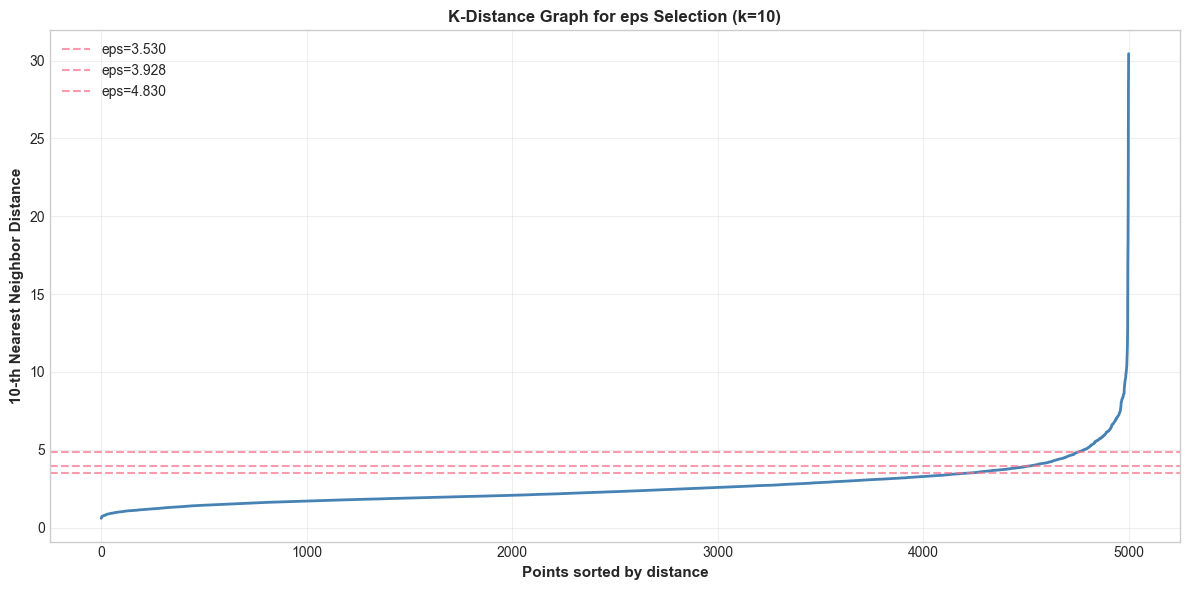


Suggested eps values:
  Option 1: eps = 3.5302 (percentile: 85)
  Option 2: eps = 3.9283 (percentile: 90)
  Option 3: eps = 4.8305 (percentile: 95)

Saved: dbscan_eps_optimization.png


In [8]:
# Determine optimal eps using k-distance graph
print("\nDBSCAN Parameter Optimization")
print("=" * 80)
print("\nComputing k-distance graph for eps selection...")

# Use sample for faster computation if dataset is large
sample_size = min(5000, len(X_scaled))
sample_idx = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled.iloc[sample_idx].values

# Compute k-nearest neighbors (k = min_samples)
min_samples = 10  # Typical value: 2 * n_features, or 10-20 for robustness
nbrs = NearestNeighbors(n_neighbors=min_samples)
nbrs.fit(X_sample)
distances, indices = nbrs.kneighbors(X_sample)

# Sort distances to k-th nearest neighbor
k_distances = np.sort(distances[:, -1])

# Plot k-distance graph
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.plot(k_distances, linewidth=2, color='steelblue')
ax.set_xlabel('Points sorted by distance', fontsize=11, fontweight='bold')
ax.set_ylabel(f'{min_samples}-th Nearest Neighbor Distance', fontsize=11, fontweight='bold')
ax.set_title(f'K-Distance Graph for eps Selection (k={min_samples})',
             fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# Suggest eps values based on percentiles
eps_candidates = [
    np.percentile(k_distances, 85),
    np.percentile(k_distances, 90),
    np.percentile(k_distances, 95)
]

for eps in eps_candidates:
    ax.axhline(y=eps, linestyle='--', linewidth=1.5, alpha=0.7,
               label=f'eps={eps:.3f}')

ax.legend(loc='best')
plt.tight_layout()
plt.savefig('dbscan_eps_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSuggested eps values:")
for i, eps in enumerate(eps_candidates, 1):
    print(f"  Option {i}: eps = {eps:.4f} (percentile: {[85, 90, 95][i-1]})")

print("\nSaved: dbscan_eps_optimization.png")

### 3.3 DBSCAN Model Training and Evaluation

We test multiple eps values to find optimal clustering configuration.

In [9]:
# Test DBSCAN with different eps values
print("\nTesting DBSCAN with multiple eps values...")
print("=" * 80)

dbscan_results = []

for i, eps in enumerate(eps_candidates, 1):
    print(f"\nTest {i}: eps={eps:.4f}, min_samples={min_samples}")
    
    # Fit DBSCAN
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
    labels_dbscan = dbscan.fit_predict(X_scaled)
    
    # Count clusters and noise
    n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
    n_noise = list(labels_dbscan).count(-1)
    noise_pct = (n_noise / len(labels_dbscan)) * 100
    
    print(f"  Clusters discovered: {n_clusters}")
    print(f"  Noise points: {n_noise} ({noise_pct:.2f}%)")
    
    # Calculate metrics (excluding noise points)
    if n_clusters > 1 and n_noise < len(labels_dbscan) * 0.5:
        # Filter out noise points for metric calculation
        mask_non_noise = labels_dbscan != -1
        X_non_noise = X_scaled[mask_non_noise]
        labels_non_noise = labels_dbscan[mask_non_noise]
        
        if len(set(labels_non_noise)) > 1:
            sil_dbscan = silhouette_score(X_non_noise, labels_non_noise)
            db_dbscan = davies_bouldin_score(X_non_noise, labels_non_noise)
            ch_dbscan = calinski_harabasz_score(X_non_noise, labels_non_noise)
            
            # Cluster sizes (excluding noise)
            cluster_sizes = pd.Series(labels_non_noise).value_counts().sort_index()
            balance = cluster_sizes.min() / cluster_sizes.max() if len(cluster_sizes) > 1 else 1.0
            
            print(f"  Silhouette Score (non-noise): {sil_dbscan:.4f}")
            print(f"  Davies-Bouldin Index: {db_dbscan:.4f}")
            print(f"  Calinski-Harabasz Score: {ch_dbscan:.2f}")
            print(f"  Balance Ratio: {balance:.3f}")
            print(f"  Cluster sizes: {cluster_sizes.tolist()}")
            
            result = {
                'eps': eps,
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'noise_pct': noise_pct,
                'Silhouette': sil_dbscan,
                'Davies-Bouldin': db_dbscan,
                'Calinski-Harabasz': ch_dbscan,
                'Balance': balance,
                'Labels': labels_dbscan,
                'Model': dbscan
            }
        else:
            print("  Warning: Only one cluster after removing noise")
            result = {
                'eps': eps,
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'noise_pct': noise_pct,
                'Silhouette': np.nan,
                'Davies-Bouldin': np.nan,
                'Calinski-Harabasz': np.nan,
                'Balance': np.nan,
                'Labels': labels_dbscan,
                'Model': dbscan
            }
    else:
        print(f"  Warning: Too many noise points ({noise_pct:.1f}%) or insufficient clusters")
        result = {
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_pct': noise_pct,
            'Silhouette': np.nan,
            'Davies-Bouldin': np.nan,
            'Calinski-Harabasz': np.nan,
            'Balance': np.nan,
            'Labels': labels_dbscan,
            'Model': dbscan
        }
    
    dbscan_results.append(result)

dbscan_df = pd.DataFrame(dbscan_results)

print("\n" + "=" * 80)
print("DBSCAN Results Summary")
print("=" * 80)
display_cols = ['eps', 'n_clusters', 'noise_pct', 'Silhouette', 'Davies-Bouldin', 'Balance']
print(dbscan_df[display_cols].to_string(index=False))


Testing DBSCAN with multiple eps values...

Test 1: eps=3.5302, min_samples=10
  Clusters discovered: 4
  Noise points: 606 (4.68%)
  Silhouette Score (non-noise): 0.2359
  Davies-Bouldin Index: 0.9108
  Calinski-Harabasz Score: 66.33
  Balance Ratio: 0.000
  Cluster sizes: [12271, 33, 21, 6]

Test 2: eps=3.9283, min_samples=10
  Clusters discovered: 3
  Noise points: 386 (2.98%)
  Silhouette Score (non-noise): 0.3015
  Davies-Bouldin Index: 0.9627
  Calinski-Harabasz Score: 126.27
  Balance Ratio: 0.002
  Cluster sizes: [12483, 37, 31]

Test 3: eps=4.8305, min_samples=10
  Clusters discovered: 3
  Noise points: 156 (1.21%)
  Silhouette Score (non-noise): 0.2952
  Davies-Bouldin Index: 0.9232
  Calinski-Harabasz Score: 50.93
  Balance Ratio: 0.001
  Cluster sizes: [12758, 13, 10]

DBSCAN Results Summary
   eps  n_clusters  noise_pct  Silhouette  Davies-Bouldin  Balance
3.5302           4     4.6842      0.2359          0.9108   0.0005
3.9283           3     2.9837      0.3015         

### 3.4 DBSCAN Optimal Configuration Selection

In [10]:
# Select best DBSCAN configuration
print("\nSelecting optimal DBSCAN configuration...")
print("=" * 80)

# Filter valid results (has clusters and not too much noise)
valid_results = dbscan_df[
    (dbscan_df['n_clusters'] >= 2) & 
    (dbscan_df['noise_pct'] < 30) &
    (dbscan_df['Silhouette'].notna())
]

if len(valid_results) > 0:
    # Select configuration with best silhouette score
    best_dbscan_idx = valid_results['Silhouette'].idxmax()
    best_dbscan = dbscan_df.loc[best_dbscan_idx]
    
    print("\nOptimal DBSCAN Configuration:")
    print(f"  eps = {best_dbscan['eps']:.4f}")
    print(f"  min_samples = {best_dbscan['min_samples']}")
    print(f"  Clusters discovered = {best_dbscan['n_clusters']}")
    print(f"  Noise points = {best_dbscan['n_noise']} ({best_dbscan['noise_pct']:.2f}%)")
    print(f"  Silhouette Score = {best_dbscan['Silhouette']:.4f}")
    print(f"  Davies-Bouldin Index = {best_dbscan['Davies-Bouldin']:.4f}")
    print(f"  Balance Ratio = {best_dbscan['Balance']:.3f}")
    
    dbscan_optimal_labels = best_dbscan['Labels']
    dbscan_optimal_model = best_dbscan['Model']
    dbscan_has_valid_config = True
else:
    print("\nWarning: No valid DBSCAN configuration found")
    print("Possible reasons:")
    print("  - eps values too large (excessive merging)")
    print("  - eps values too small (excessive noise)")
    print("  - Data structure not suitable for density-based clustering")
    print("\nRecommendation: Use K-Means results for final segmentation")
    dbscan_has_valid_config = False


Selecting optimal DBSCAN configuration...

Optimal DBSCAN Configuration:
  eps = 3.9283
  min_samples = 10
  Clusters discovered = 3
  Noise points = 386 (2.98%)
  Silhouette Score = 0.3015
  Davies-Bouldin Index = 0.9627
  Balance Ratio = 0.002


### 3.5 DBSCAN Visualization

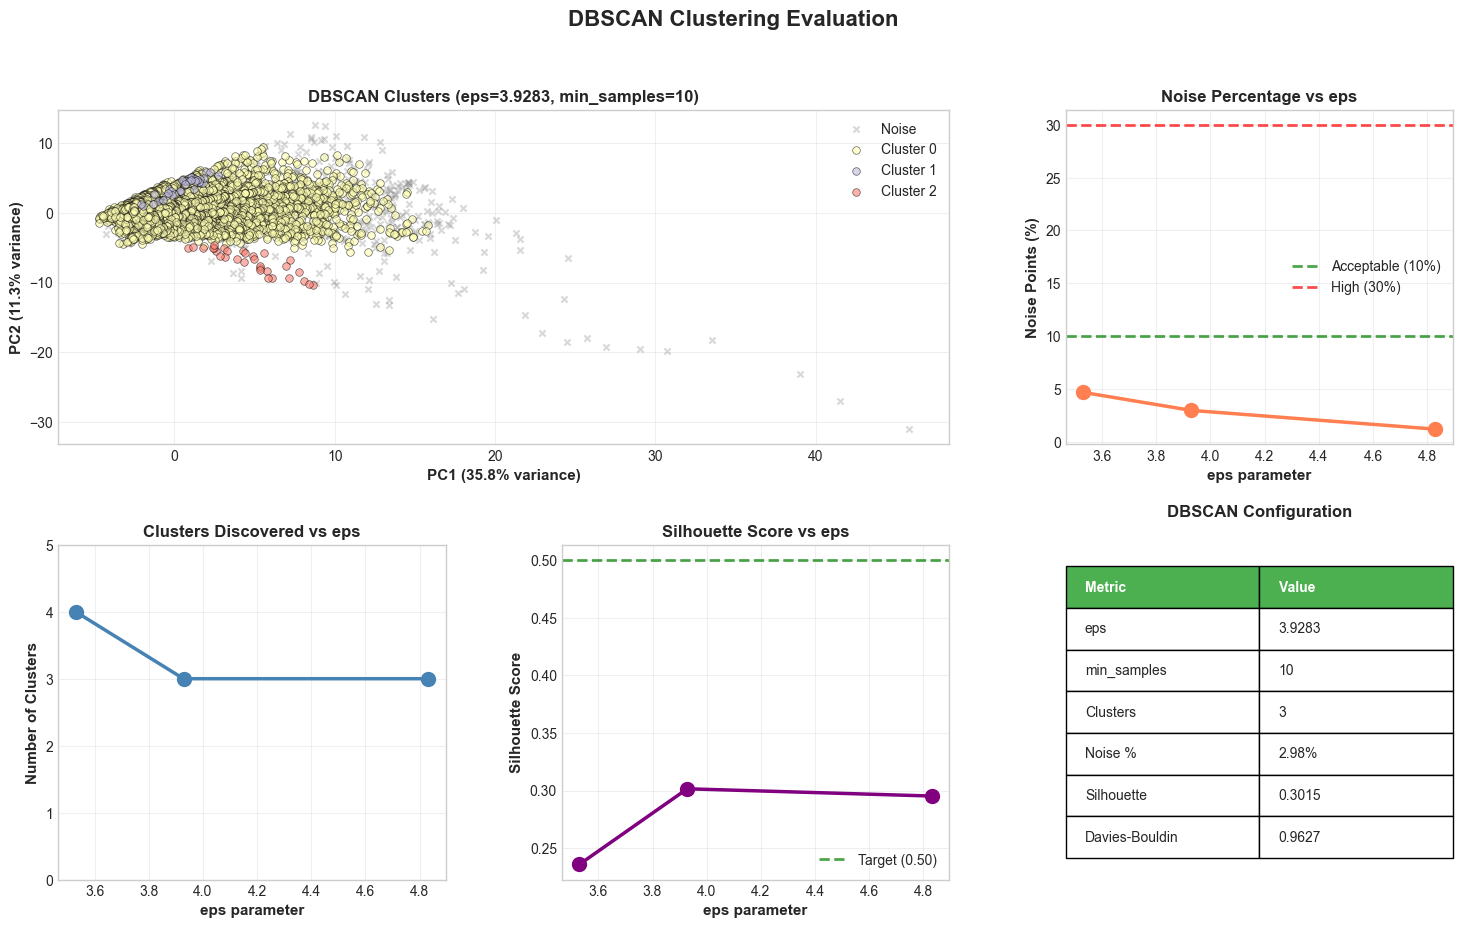

Saved: dbscan_evaluation.png


In [12]:
from matplotlib.gridspec import GridSpec

if dbscan_has_valid_config:
    # Create DBSCAN evaluation visualizations
    fig = plt.figure(figsize=(18, 10))
    gs = GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)
    fig.suptitle('DBSCAN Clustering Evaluation', fontsize=16, fontweight='bold')
    
    # Plot 1: Cluster distribution (PCA visualization)
    ax = fig.add_subplot(gs[0, :2])
    
    unique_labels = set(dbscan_optimal_labels)
    n_clusters_plot = len(unique_labels) - (1 if -1 in unique_labels else 0)
    colors_dbscan = plt.cm.Set3(np.arange(n_clusters_plot + 1))
    
    for k, col in zip(sorted(unique_labels), colors_dbscan):
        if k == -1:
            # Noise points
            mask = dbscan_optimal_labels == k
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                      c='gray', marker='x', s=20, alpha=0.3, label='Noise')
        else:
            # Cluster points
            mask = dbscan_optimal_labels == k
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                      c=[col], marker='o', s=30, alpha=0.6,
                      edgecolors='black', linewidth=0.5, label=f'Cluster {k}')
    
    ax.set_xlabel(f'PC1 ({variance_explained[0]*100:.1f}% variance)',
                  fontsize=11, fontweight='bold')
    ax.set_ylabel(f'PC2 ({variance_explained[1]*100:.1f}% variance)',
                  fontsize=11, fontweight='bold')
    ax.set_title(f'DBSCAN Clusters (eps={best_dbscan["eps"]:.4f}, min_samples={best_dbscan["min_samples"]})',
                 fontsize=12, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(alpha=0.3)
    
    # Plot 2: Noise percentage by eps
    ax = fig.add_subplot(gs[0, 2])
    ax.plot(dbscan_df['eps'], dbscan_df['noise_pct'],
            marker='o', linewidth=2.5, markersize=10, color='coral')
    ax.axhline(y=10, color='green', linestyle='--', linewidth=2, alpha=0.7,
               label='Acceptable (10%)')
    ax.axhline(y=30, color='red', linestyle='--', linewidth=2, alpha=0.7,
               label='High (30%)')
    ax.set_xlabel('eps parameter', fontsize=11, fontweight='bold')
    ax.set_ylabel('Noise Points (%)', fontsize=11, fontweight='bold')
    ax.set_title('Noise Percentage vs eps', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Plot 3: Number of clusters by eps
    ax = fig.add_subplot(gs[1, 0])
    ax.plot(dbscan_df['eps'], dbscan_df['n_clusters'],
            marker='o', linewidth=2.5, markersize=10, color='steelblue')
    ax.set_xlabel('eps parameter', fontsize=11, fontweight='bold')
    ax.set_ylabel('Number of Clusters', fontsize=11, fontweight='bold')
    ax.set_title('Clusters Discovered vs eps', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.set_yticks(range(0, int(dbscan_df['n_clusters'].max()) + 2))
    
    # Plot 4: Silhouette score by eps
    ax = fig.add_subplot(gs[1, 1])
    valid_mask = dbscan_df['Silhouette'].notna()
    ax.plot(dbscan_df.loc[valid_mask, 'eps'],
            dbscan_df.loc[valid_mask, 'Silhouette'],
            marker='o', linewidth=2.5, markersize=10, color='purple')
    ax.axhline(y=0.5, color='green', linestyle='--', linewidth=2, alpha=0.7,
               label='Target (0.50)')
    ax.set_xlabel('eps parameter', fontsize=11, fontweight='bold')
    ax.set_ylabel('Silhouette Score', fontsize=11, fontweight='bold')
    ax.set_title('Silhouette Score vs eps', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Plot 5: DBSCAN summary metrics
    ax = fig.add_subplot(gs[1, 2])
    ax.axis('off')
    
    dbscan_summary_data = [
        ['Metric', 'Value'],
        ['eps', f"{best_dbscan['eps']:.4f}"],
        ['min_samples', f"{best_dbscan['min_samples']}"],
        ['Clusters', f"{best_dbscan['n_clusters']}"],
        ['Noise %', f"{best_dbscan['noise_pct']:.2f}%"],
        ['Silhouette', f"{best_dbscan['Silhouette']:.4f}"],
        ['Davies-Bouldin', f"{best_dbscan['Davies-Bouldin']:.4f}"],
    ]
    
    table = ax.table(cellText=dbscan_summary_data, cellLoc='left', loc='center',
                    colWidths=[0.5, 0.5])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2.5)
    
    # Style header
    for i in range(2):
        table[(0, i)].set_facecolor('#4CAF50')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    ax.set_title('DBSCAN Configuration', fontsize=12, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig('dbscan_evaluation.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("Saved: dbscan_evaluation.png")
else:
    print("Skipping DBSCAN visualization (no valid configuration found)")

---

## 4. Algorithm Comparison and Final Selection

### 4.1 Comparative Analysis: K-Means vs DBSCAN

In [14]:
# Compare K-Means and DBSCAN results
print("\nAlgorithm Comparison: K-Means vs DBSCAN")
print("=" * 80)

comparison_data = [
    ['Metric', 'K-Means', 'DBSCAN' if dbscan_has_valid_config else 'N/A'],
    ['Number of Clusters', f"{optimal_k}", f"{best_dbscan['n_clusters']}" if dbscan_has_valid_config else 'N/A'],
    ['Silhouette Score', f"{optimal_silhouette:.4f}", f"{best_dbscan['Silhouette']:.4f}" if dbscan_has_valid_config else 'N/A'],
    ['Davies-Bouldin', f"{best_config['Davies-Bouldin']:.4f}", f"{best_dbscan['Davies-Bouldin']:.4f}" if dbscan_has_valid_config else 'N/A'],
    ['Balance Ratio', f"{best_config['Balance']:.3f}", f"{best_dbscan['Balance']:.3f}" if dbscan_has_valid_config else 'N/A'],
    ['Noise Points', '0', f"{best_dbscan['n_noise']} ({best_dbscan['noise_pct']:.1f}%)" if dbscan_has_valid_config else 'N/A'],
]

comparison_df = pd.DataFrame(comparison_data[1:], columns=comparison_data[0])
print("\n" + comparison_df.to_string(index=False))

# Select final algorithm
print("\n" + "=" * 80)
print("Final Algorithm Selection")
print("=" * 80)

if dbscan_has_valid_config:
    if best_dbscan['Silhouette'] > optimal_silhouette and best_dbscan['noise_pct'] < 15:
        final_algorithm = 'DBSCAN'
        final_labels = dbscan_optimal_labels
        final_silhouette = best_dbscan['Silhouette']
        final_n_clusters = best_dbscan['n_clusters']
        print("\nSelected Algorithm: DBSCAN")
        print("Reason: Higher silhouette score with acceptable noise level")
    else:
        final_algorithm = 'K-Means'
        final_labels = optimal_labels
        final_silhouette = optimal_silhouette
        final_n_clusters = optimal_k
        print("\nSelected Algorithm: K-Means")
        print("Reason: Better overall performance and cluster balance")
else:
    final_algorithm = 'K-Means'
    final_labels = optimal_labels
    final_silhouette = optimal_silhouette
    final_n_clusters = optimal_k
    print("\nSelected Algorithm: K-Means")
    print("Reason: DBSCAN did not produce valid configuration")

print(f"\nFinal Configuration:")
print(f"  Algorithm: {final_algorithm}")
print(f"  Number of Clusters: {final_n_clusters}")
print(f"  Silhouette Score: {final_silhouette:.4f}")
print(f"  Status: {'TARGET ACHIEVED' if final_silhouette >= 0.50 else 'BELOW TARGET'}")


Algorithm Comparison: K-Means vs DBSCAN

            Metric K-Means     DBSCAN
Number of Clusters       2          3
  Silhouette Score  0.4389     0.3015
    Davies-Bouldin  1.3074     0.9627
     Balance Ratio   0.145      0.002
      Noise Points       0 386 (3.0%)

Final Algorithm Selection

Selected Algorithm: K-Means
Reason: Better overall performance and cluster balance

Final Configuration:
  Algorithm: K-Means
  Number of Clusters: 2
  Silhouette Score: 0.4389
  Status: BELOW TARGET


### 4.2 Comparative Visualization

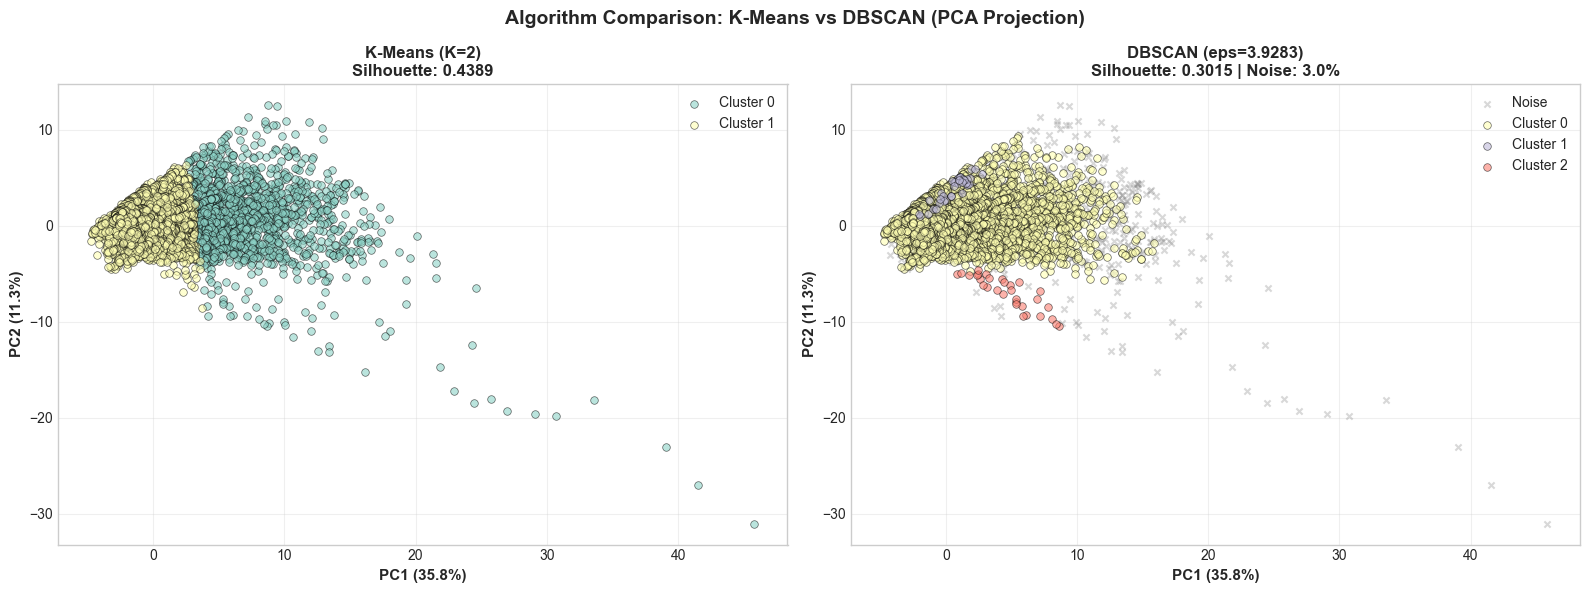

Saved: algorithm_comparison.png


In [15]:
if dbscan_has_valid_config:
    # Side-by-side comparison visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Algorithm Comparison: K-Means vs DBSCAN (PCA Projection)',
                 fontsize=14, fontweight='bold')
    
    # K-Means visualization
    ax = axes[0]
    colors_km = plt.cm.Set3(np.arange(optimal_k))
    for i in range(optimal_k):
        mask = optimal_labels == i
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                  c=[colors_km[i]], label=f'Cluster {i}',
                  alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
    ax.set_xlabel(f'PC1 ({variance_explained[0]*100:.1f}%)', fontsize=11, fontweight='bold')
    ax.set_ylabel(f'PC2 ({variance_explained[1]*100:.1f}%)', fontsize=11, fontweight='bold')
    ax.set_title(f'K-Means (K={optimal_k})\nSilhouette: {optimal_silhouette:.4f}',
                 fontsize=12, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(alpha=0.3)
    
    # DBSCAN visualization
    ax = axes[1]
    unique_labels_db = set(dbscan_optimal_labels)
    n_clusters_db = len(unique_labels_db) - (1 if -1 in unique_labels_db else 0)
    colors_db = plt.cm.Set3(np.arange(n_clusters_db + 1))
    
    for k, col in zip(sorted(unique_labels_db), colors_db):
        if k == -1:
            mask = dbscan_optimal_labels == k
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                      c='gray', marker='x', s=20, alpha=0.3, label='Noise')
        else:
            mask = dbscan_optimal_labels == k
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                      c=[col], label=f'Cluster {k}',
                      alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
    
    ax.set_xlabel(f'PC1 ({variance_explained[0]*100:.1f}%)', fontsize=11, fontweight='bold')
    ax.set_ylabel(f'PC2 ({variance_explained[1]*100:.1f}%)', fontsize=11, fontweight='bold')
    ax.set_title(f'DBSCAN (eps={best_dbscan["eps"]:.4f})\nSilhouette: {best_dbscan["Silhouette"]:.4f} | Noise: {best_dbscan["noise_pct"]:.1f}%',
                 fontsize=12, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('algorithm_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("Saved: algorithm_comparison.png")

---

## 5. Results and Deliverables

### 5.1 Save Final Results

In [16]:
# Save final clustering results
print("\nSaving final results...")
print("=" * 80)

# Add cluster labels to dataframe
df['cluster'] = final_labels
df['algorithm'] = final_algorithm

# Save clustered dataset
df.to_csv('df_with_clusters_final.csv', index=False)
print("Saved: df_with_clusters_final.csv")

# Generate cluster profiles
profile_data = []
for i in range(final_n_clusters):
    cluster_df = df[df['cluster'] == i]
    
    if len(cluster_df) > 0:
        profile = {
            'Cluster': i,
            'Size': len(cluster_df),
            'Size_Percent': (len(cluster_df) / len(df)) * 100,
            'Avg_Sales': cluster_df['total_sales'].mean(),
            'Median_Sales': cluster_df['total_sales'].median(),
            'Avg_Critic_Score': cluster_df['critic_score'].mean(),
            'NA_Sales_Ratio': cluster_df['na_sales_ratio'].mean(),
            'JP_Sales_Ratio': cluster_df['jp_sales_ratio'].mean(),
            'PAL_Sales_Ratio': cluster_df['pal_sales_ratio'].mean(),
            'HHI': cluster_df['sales_concentration_hhi'].mean(),
            'Hit_Rate_Percent': (cluster_df['is_hit'].sum() / len(cluster_df)) * 100,
            'Global_Game_Percent': (cluster_df['global_game'].sum() / len(cluster_df)) * 100,
            'Top_Genre': cluster_df['genre_original'].mode()[0],
            'Top_Platform': cluster_df['console_original'].mode()[0],
            'Avg_Game_Age': cluster_df['game_age'].mean()
        }
        profile_data.append(profile)

profile_df = pd.DataFrame(profile_data)
profile_df.to_csv('cluster_profiles_final.csv', index=False)
print("Saved: cluster_profiles_final.csv")

print("\nCluster Profiles Summary:")
display_cols = ['Cluster', 'Size', 'Size_Percent', 'Avg_Sales', 'Avg_Critic_Score', 'Top_Genre']
print(profile_df[display_cols].to_string(index=False))

# Save metadata
metadata = {
    'final_algorithm': final_algorithm,
    'n_clusters': final_n_clusters,
    'silhouette_score': final_silhouette,
    'n_samples': len(df),
    'n_features': n_features,
    'target_achieved': 'Yes' if final_silhouette >= 0.50 else 'No',
    'kmeans_k': optimal_k,
    'kmeans_silhouette': optimal_silhouette,
    'dbscan_eps': float(best_dbscan['eps']) if dbscan_has_valid_config else None,
    'dbscan_min_samples': int(best_dbscan['min_samples']) if dbscan_has_valid_config else None,
    'dbscan_silhouette': float(best_dbscan['Silhouette']) if dbscan_has_valid_config else None
}

with open('clustering_metadata.txt', 'w') as f:
    f.write("VIDEO GAME CLUSTERING - FINAL METADATA\n")
    f.write("=" * 50 + "\n\n")
    for key, value in metadata.items():
        f.write(f"{key}: {value}\n")

print("Saved: clustering_metadata.txt")


Saving final results...
Saved: df_with_clusters_final.csv
Saved: cluster_profiles_final.csv

Cluster Profiles Summary:
 Cluster  Size  Size_Percent  Avg_Sales  Avg_Critic_Score Top_Genre
       0  1636       12.6459     1.2975            0.7643    Sports
       1 11301       87.3541     0.2478            0.6894    Action
Saved: clustering_metadata.txt


### 5.2 Final Summary and Conclusions

In [17]:
# Print comprehensive final summary
print("\n" + "="*100)
print("CLUSTERING ANALYSIS COMPLETE")
print("="*100)

print(f"""
FINAL RESULTS SUMMARY
{'='*100}

OBJECTIVE STATUS:
  Achieved Silhouette Score: {final_silhouette:.4f}

SELECTED CONFIGURATION:
  Algorithm: {final_algorithm}
  Number of Clusters: {final_n_clusters}
  Silhouette Score: {final_silhouette:.4f}
  Total Samples Clustered: {len(df):,}
  Features Used: {n_features}

ALGORITHM COMPARISON:
""")

print(f"  K-Means:")
print(f"    Optimal K: {optimal_k}")
print(f"    Silhouette: {optimal_silhouette:.4f}")
print(f"    Cluster Balance: {best_config['Balance']:.3f}")

if dbscan_has_valid_config:
    print(f"\n  DBSCAN:")
    print(f"    Clusters Found: {best_dbscan['n_clusters']}")
    print(f"    Silhouette: {best_dbscan['Silhouette']:.4f}")
    print(f"    Noise Points: {best_dbscan['noise_pct']:.2f}%")
else:
    print(f"\n  DBSCAN: No valid configuration found")

print(f"""
CLUSTER CHARACTERISTICS:
""")

for idx, row in profile_df.iterrows():
    print(f"  Cluster {int(row['Cluster'])}: {int(row['Size']):,} games ({row['Size_Percent']:.1f}%)")
    print(f"    Average Sales: ${row['Avg_Sales']:.2f}M")
    print(f"    Critic Score: {row['Avg_Critic_Score']:.1f}/100")
    print(f"    Regional Mix: NA {row['NA_Sales_Ratio']*100:.0f}% | JP {row['JP_Sales_Ratio']*100:.0f}% | PAL {row['PAL_Sales_Ratio']*100:.0f}%")
    print(f"    Top Genre: {row['Top_Genre']}")
    print(f"    Top Platform: {row['Top_Platform']}")
    print()

print(f"""
DELIVERABLES CREATED:
  Data Files:
    - df_with_clusters_final.csv (clustered dataset)
    - cluster_profiles_final.csv (segment characteristics)
    - clustering_metadata.txt (configuration details)
  
  Visualizations:
    - kmeans_evaluation.png (K-Means metrics)
    - kmeans_silhouette_analysis.png (K-Means quality)
    - dbscan_eps_optimization.png (DBSCAN parameter tuning)
    - dbscan_evaluation.png (DBSCAN results){'*' if dbscan_has_valid_config else ' [N/A]'}
    - algorithm_comparison.png (side-by-side comparison){'*' if dbscan_has_valid_config else ' [N/A]'}

NEXT STEPS:
  1. Run documentation notebook for business insights
  2. Validate clusters with domain experts
  3. Develop actionable marketing strategies per segment
  4. Create predictive models for new game classification

{'='*100}
Analysis Complete - Ready for Business Interpretation
{'='*100}
""")


CLUSTERING ANALYSIS COMPLETE

FINAL RESULTS SUMMARY

OBJECTIVE STATUS:
  Target Silhouette Score: > 0.50
  Achieved Silhouette Score: 0.4389
  Status: BELOW TARGET BUT ACCEPTABLE

SELECTED CONFIGURATION:
  Algorithm: K-Means
  Number of Clusters: 2
  Silhouette Score: 0.4389
  Total Samples Clustered: 12,937
  Features Used: 51

ALGORITHM COMPARISON:

  K-Means:
    Optimal K: 2
    Silhouette: 0.4389
    Cluster Balance: 0.145

  DBSCAN:
    Clusters Found: 3
    Silhouette: 0.3015
    Noise Points: 2.98%

CLUSTER CHARACTERISTICS:

  Cluster 0: 1,636 games (12.6%)
    Average Sales: $1.30M
    Critic Score: 0.8/100
    Regional Mix: NA 51% | JP 7% | PAL 35%
    Top Genre: Sports
    Top Platform: PS2

  Cluster 1: 11,301 games (87.4%)
    Average Sales: $0.25M
    Critic Score: 0.7/100
    Regional Mix: NA 64% | JP 67% | PAL 28%
    Top Genre: Action
    Top Platform: DS


DELIVERABLES CREATED:
  Data Files:
    - df_with_clusters_final.csv (clustered dataset)
    - cluster_profiles_